# Miss Sampling Plot Demo

Mock notebook for the artifact we want in MLflow: one contact sheet per miss, using the exact sampled frame indices.

In [6]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import VideoMAEImageProcessor

from aitraf.processing.models.video_mae import (
    load_processed_video_frames,
    sample_video_frame_indices,
)

In [7]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
clips_dir = repo_root / "data/clips"
manifest_path = repo_root / "data/manifests/score_prediction_binary/test.jsonl"
model_cache_dir = repo_root / "models/video_mae_cache"
backbone = "MCG-NJU/videomae-base"
num_frames = 16
sampling_dist = "gaussian"
processor = VideoMAEImageProcessor.from_pretrained(
    backbone, cache_dir=str(model_cache_dir)
)


def load_local_manifest_rows(limit: int = 2) -> list[dict]:
    rows = []
    with manifest_path.open() as fh:
        for line in fh:
            row = json.loads(line)
            clip_path = clips_dir / row["video_id"]
            if clip_path.exists():
                row["clip_path"] = clip_path
                rows.append(row)
            if len(rows) == limit:
                break

    if rows:
        return rows

    clip_path = next(clips_dir.glob("*.mp4"))
    return [
        {
            "video_id": clip_path.name,
            "clip_path": clip_path,
            "quality_label": "bad",
            "trick": "unknown",
            "person": "unknown",
        }
    ]


def opposite_label(label: str) -> str:
    return "good" if label == "bad" else "bad"


misses = pd.DataFrame(
    {
        **row,
        "pred_quality_label": opposite_label(row["quality_label"]),
        "pred_confidence": 0.94 - i * 0.07,
        "sampling_plot": f"miss_sampling_plots/{Path(row['video_id']).stem}.png",
    }
    for i, row in enumerate(load_local_manifest_rows())
)

misses

,video_id,s3_path,quality_label,trick,key_foot,person,execution_score,clip_path,pred_quality_label,pred_confidence,sampling_plot
0,25-12-01 21-27-45 5969-00.05.22.291-00.05.26.5...,s3://aitraf/clips/25-12-01 21-27-45 5969-00.05...,good,fs-savanah,right,Henrikas,3,/workspace/data/clips/25-12-01 21-27-45 5969-0...,bad,0.94,miss_sampling_plots/25-12-01 21-27-45 5969-00....
1,25-11-15 19-11-43 5734-00.01.28.338-00.01.32.6...,s3://aitraf/clips/25-11-15 19-11-43 5734-00.01...,bad,fs-royale,left,Henrikas,1,/workspace/data/clips/25-11-15 19-11-43 5734-0...,good,0.87,miss_sampling_plots/25-11-15 19-11-43 5734-00....


In [8]:
def load_demo_frames(clip_path: Path, *, seed: int = 42):
    """Use the same helpers the MLflow miss plots use."""

    torch.manual_seed(seed)
    frame_indices = sample_video_frame_indices(
        video_id=clip_path.name,
        local_clips_dir=clips_dir,
        num_frames=num_frames,
        sampling_dist=sampling_dist,
    )
    frames = load_processed_video_frames(
        video_id=clip_path.name,
        processor=processor,
        local_clips_dir=clips_dir,
        frame_indices=frame_indices,
    )
    return frames, frame_indices


def plot_miss_sampling_sheet(
    miss: pd.Series, frames: list[np.ndarray], *, cols: int = 4
):
    frame_indices = miss["frame_indices"]
    rows = int(np.ceil(len(frames) / cols))
    fig, axes = plt.subplots(
        rows, cols, figsize=(cols * 3.0, rows * 2.4), squeeze=False
    )

    for ax in axes.ravel():
        ax.axis("off")

    for ax, frame, frame_idx in zip(axes.ravel(), frames, frame_indices):
        ax.imshow(frame)
        ax.set_title(f"frame {frame_idx}", fontsize=10)

    title = (
        f"{miss['video_id']} | actual={miss['quality_label']} | "
        f"pred={miss['pred_quality_label']} ({miss['pred_confidence']:.2f})"
    )
    subtitle = (
        f"trick={miss['trick']} | person={miss['person']} | sampling={sampling_dist}"
    )
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.text(0.5, 0.98, subtitle, ha="center", va="top", fontsize=10)
    fig.tight_layout()
    return fig

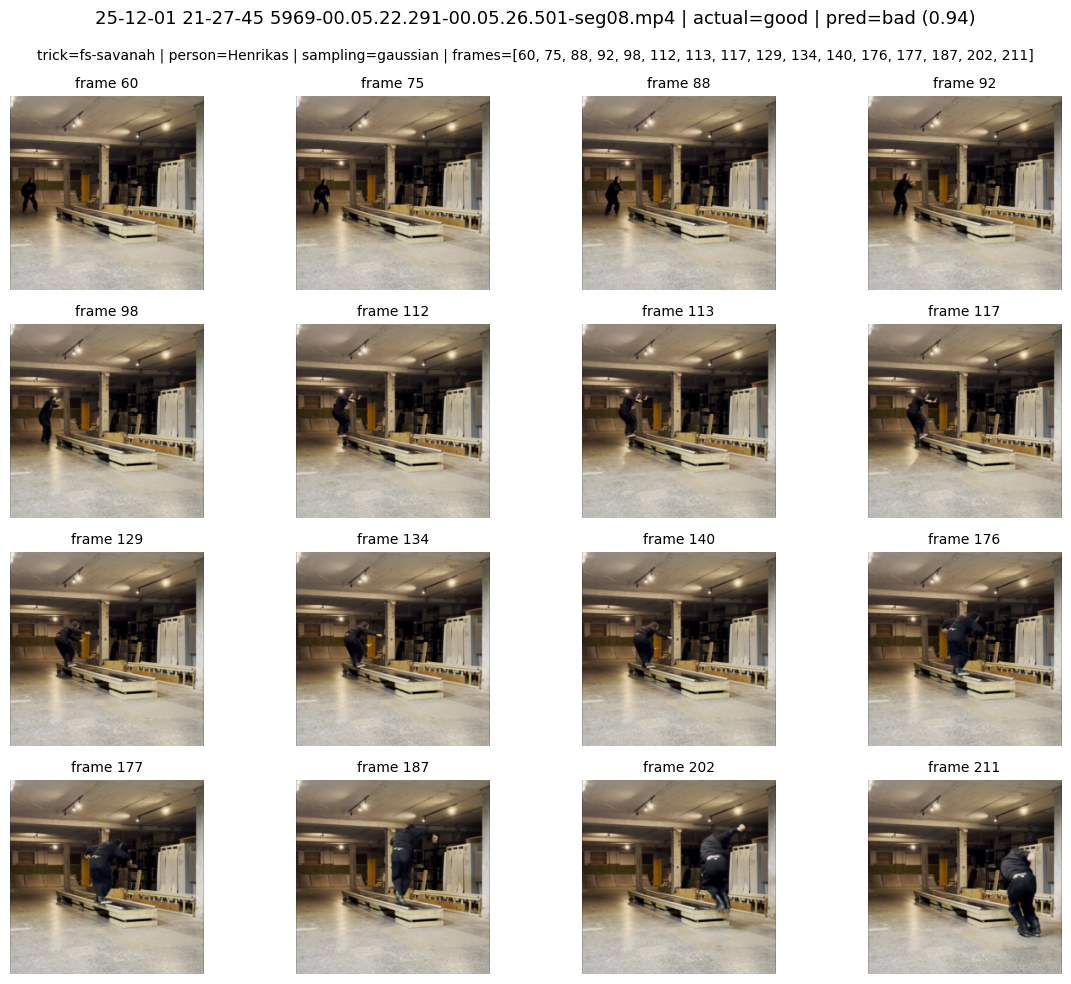

In [9]:
miss = misses.iloc[0].copy()
frames, frame_indices = load_demo_frames(miss["clip_path"])
miss["frame_indices"] = frame_indices
fig = plot_miss_sampling_sheet(miss, frames)
plt.show()

In [ ]:
output_dir = repo_root / "runs/mock_miss_sampling_plots"
output_dir.mkdir(parents=True, exist_ok=True)

for _, miss in misses.iterrows():
    miss = miss.copy()
    frames, frame_indices = load_demo_frames(miss["clip_path"])
    miss["frame_indices"] = frame_indices
    fig = plot_miss_sampling_sheet(miss, frames)
    out_path = output_dir / Path(miss["sampling_plot"]).name
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

sorted(output_dir.glob("*.png"))